**<h1> CS 5316 Project Group 9</h1>**

**<h3> Members: </h3>**
- <h4> Rahym Faisal Khan (27100057) </h4>
- <h4> Abdullah Ahmad (271000387) </h4>
- <h4> Saud Rais (23030007) </h4>

**<h1> Libraries Used </h1>**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

**<h1> Loading and Merging Datasets </h1>**

In [53]:
# Loading datasets

movies_meta = load_dataset("Pablinho/movies-dataset", split="train")
movies_meta_df = movies_meta.to_pandas()

movie_reviews_df = pd.read_csv(
    "/content/sample_data/rotten_tomatoes_movie_reviews.csv",
    engine="python",
    on_bad_lines="skip",
    encoding="utf-8"
)

movies_meta_df["title_key"] = movies_meta_df["Title"].astype(str).str.lower().str.strip()
movie_reviews_df["title_key"] = movie_reviews_df["id"].astype(str).str.lower().str.strip()
movie_reviews_df["title_key"] = movie_reviews_df["title_key"].str.replace("_", " ")

# Merging Datasets

movies_merged_df = movie_reviews_df.merge(movies_meta_df, on="title_key", how="inner", suffixes=("_review","_meta"))

# Dropping columns irrelevant for our project

movies_df = movies_merged_df.drop(["criticName",
                                   "isTopCritic",
                                   "reviewState",
                                   "publicatioName",
                                   "reviewUrl",
                                   "title_key",
                                   "Poster_Url"], axis=1)

movies_df = movies_df.dropna()
print(movies_df.shape)
print(movies_df.head(10))
display(movies_df["originalScore"].head(10))

(251809, 14)
                id  reviewId creationDate originalScore  \
0   almost_friends   2438257   2017-11-23           3/5   
5   almost_friends   2435961   2017-11-15             C   
6   almost_friends   2433187   2017-11-04           2/4   
9            klute   2712628   2020-08-11         3.5/5   
11           klute   2682098   2020-04-09         4.5/5   
16           klute   2658654   2020-01-09          7/10   
17           klute   2629700   2019-09-26           3/4   
19           klute   2609427   2019-07-27         3.5/4   
21           klute   1951113   2011-01-03            A-   
23           klute   1844744   2009-09-15          9/10   

                                           reviewText scoreSentiment  \
0   You can see where this is going from a mile aw...       POSITIVE   
5   There's gentleness to the effort that's appeal...       NEGATIVE   
6                     A romance that almost comes off       NEGATIVE   
9   Like other of Pakula's greatest films featuri

,originalScore
0,3/5
5,C
6,2/4
9,3.5/5
11,4.5/5
16,7/10
17,3/4
19,3.5/4
21,A-
23,9/10


In [54]:
movies_df.head(5)

,id,reviewId,creationDate,originalScore,reviewText,scoreSentiment,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,almost_friends,2438257,2017-11-23,3/5,You can see where this is going from a mile aw...,POSITIVE,2017-11-17,Almost Friends,"A man in his mid-20s, still living at home wit...",17.931,213,6.5,en,"Drama, Comedy"
5,almost_friends,2435961,2017-11-15,C,There's gentleness to the effort that's appeal...,NEGATIVE,2017-11-17,Almost Friends,"A man in his mid-20s, still living at home wit...",17.931,213,6.5,en,"Drama, Comedy"
6,almost_friends,2433187,2017-11-04,2/4,A romance that almost comes off,NEGATIVE,2017-11-17,Almost Friends,"A man in his mid-20s, still living at home wit...",17.931,213,6.5,en,"Drama, Comedy"
9,klute,2712628,2020-08-11,3.5/5,Like other of Pakula's greatest films featurin...,POSITIVE,1971-06-23,Klute,A high-priced call girl is forced to depend on...,18.412,284,6.8,en,"Mystery, Thriller, Crime"
11,klute,2682098,2020-04-09,4.5/5,There is a timelessness to the freaky-ness and...,POSITIVE,1971-06-23,Klute,A high-priced call girl is forced to depend on...,18.412,284,6.8,en,"Mystery, Thriller, Crime"


In [55]:
movies_df.columns

Index(['id', 'reviewId', 'creationDate', 'originalScore', 'reviewText',
       'scoreSentiment', 'Release_Date', 'Title', 'Overview', 'Popularity',
       'Vote_Count', 'Vote_Average', 'Original_Language', 'Genre'],
      dtype='object')

**<h1> Data Preprocessing </h1>**

In [56]:
# Check for columns having null values

movies_df.isnull().sum()

# Cleaning columns containing textual data

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return " ".join(tokens)

cols_to_be_cleaned = ["reviewText", "Title", "Genre", "Original_Language", "Overview"]

for col in cols_to_be_cleaned:
    movies_df[col] = movies_df[col].astype(str).apply(clean_text)

# Mapping grade scores in originalScore column to numerical scores

def numeric_part(score):
    try:
        s = str(score).strip()
        m = re.match(r'^(\d+(\.\d+)?)\s*/\s*(\d+(\.\d+)?)$', s)
        if not m:
            return np.nan
        num = float(m.group(1))
        den = float(m.group(3))
        if den == 0:
            return np.nan
        return (num / den) * 10 if den != 10 else num
    except Exception:
        return np.nan

movies_df["numeric_score"] = movies_df["originalScore"].apply(numeric_part)

mean_val = movies_df["numeric_score"].mean()
std_val = movies_df["numeric_score"].std()

def map_grade(score):
    s = str(score).strip().upper()

    if re.match(r'^\d+(\.\d+)?/\d+(\.\d+)?$', s):
        return np.nan

    mapping = {
        "A+": mean_val + 1.0 * std_val,
        "A":  mean_val + 0.75 * std_val,
        "A-": mean_val + 0.5 * std_val,
        "B+": mean_val + 0.25 * std_val,
        "B":  mean_val,
        "B-": mean_val - 0.25 * std_val,
        "C+": mean_val - 0.5 * std_val,
        "C":  mean_val - 0.75 * std_val,
        "C-": mean_val - 1.0 * std_val,
        "D+": mean_val - 1.25 * std_val,
        "D":  mean_val - 1.5 * std_val,
        "D-": mean_val - 1.75 * std_val,
        "F":  mean_val - 2.0 * std_val
    }

    val = mapping.get(s, np.nan)
    if not np.isnan(val):
        val = max(0, min(10, val))
    return val

movies_df["numeric_score_out_of_10"] = movies_df.apply(
    lambda row: row["numeric_score"]
    if not np.isnan(row["numeric_score"])
    else map_grade(row["originalScore"]),
    axis=1
)

movies_df["numeric_score_out_of_10"] = movies_df["numeric_score_out_of_10"].clip(0, 10)

print(movies_df[["originalScore", "numeric_score_out_of_10"]].head(10))

movies_df.drop(columns=["numeric_score"], inplace=True)
print(movies_df.columns)

# Drop duplicates (if any)

movies_df.drop_duplicates(inplace=True)

print(movies_df.head(10))

   originalScore  numeric_score_out_of_10
0            3/5                 6.000000
5              C                 4.864459
6            2/4                 5.000000
9          3.5/5                 7.000000
11         4.5/5                 9.000000
16          7/10                 7.000000
17           3/4                 7.500000
19         3.5/4                 8.750000
21            A-                 7.534299
23          9/10                 9.000000
Index(['id', 'reviewId', 'creationDate', 'originalScore', 'reviewText',
       'scoreSentiment', 'Release_Date', 'Title', 'Overview', 'Popularity',
       'Vote_Count', 'Vote_Average', 'Original_Language', 'Genre',
       'numeric_score_out_of_10'],
      dtype='object')
                id  reviewId creationDate originalScore  \
0   almost_friends   2438257   2017-11-23           3/5   
5   almost_friends   2435961   2017-11-15             C   
6   almost_friends   2433187   2017-11-04           2/4   
9            klute   2712628  

In [57]:
movies_df.head()

,id,reviewId,creationDate,originalScore,reviewText,scoreSentiment,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,numeric_score_out_of_10
0,almost_friends,2438257,2017-11-23,3/5,you can see where this is going from a mile aw...,POSITIVE,2017-11-17,almost friend,a man in his mid 20 still living at home with ...,17.931,213,6.5,en,drama comedy,6.000000
5,almost_friends,2435961,2017-11-15,C,there s gentleness to the effort that s appeal...,NEGATIVE,2017-11-17,almost friend,a man in his mid 20 still living at home with ...,17.931,213,6.5,en,drama comedy,4.864459
6,almost_friends,2433187,2017-11-04,2/4,a romance that almost come off,NEGATIVE,2017-11-17,almost friend,a man in his mid 20 still living at home with ...,17.931,213,6.5,en,drama comedy,5.000000
9,klute,2712628,2020-08-11,3.5/5,like other of pakula s greatest film featuring...,POSITIVE,1971-06-23,klute,a high priced call girl is forced to depend on...,18.412,284,6.8,en,mystery thriller crime,7.000000
11,klute,2682098,2020-04-09,4.5/5,there is a timelessness to the freaky ness and...,POSITIVE,1971-06-23,klute,a high priced call girl is forced to depend on...,18.412,284,6.8,en,mystery thriller crime,9.000000


**<h1> Exploratory Data Analysis (EDA) </h1>**

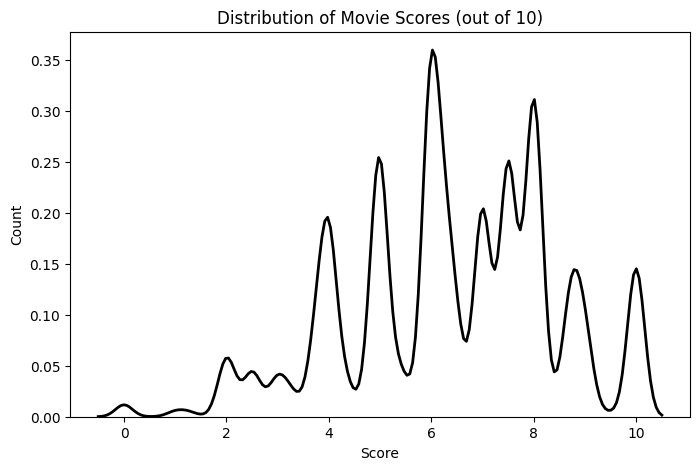

Average score: 6.385603423921046
Standard deviation: 2.012650602313268
Top 10 Most Common Genres:
 Genre
drama        120607
comedy        81921
thriller      72027
action        64381
adventure     47622
crime         39301
romance       38589
fiction       32336
science       32336
horror        31107
Name: count, dtype: int64


/tmp/ipython-input-2609505349.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")


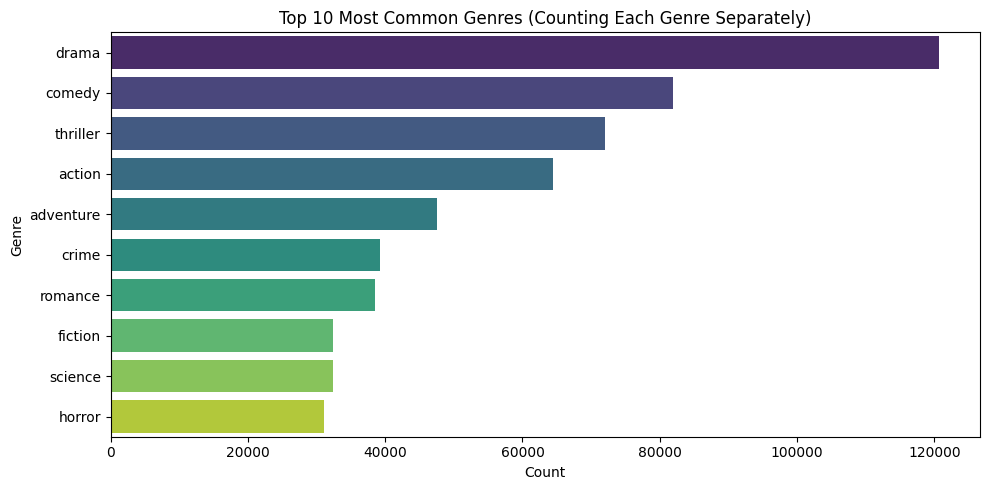

Top 10 Genres by Average Score:
 Genre
documentary    7.487777
history        7.009485
war            6.878890
drama          6.792056
western        6.756155
animation      6.717530
music          6.495332
crime          6.403932
mystery        6.390505
romance        6.376101
Name: numeric_score_out_of_10, dtype: float64


/tmp/ipython-input-2609505349.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_scores.values, y=genre_scores.index, palette="coolwarm")


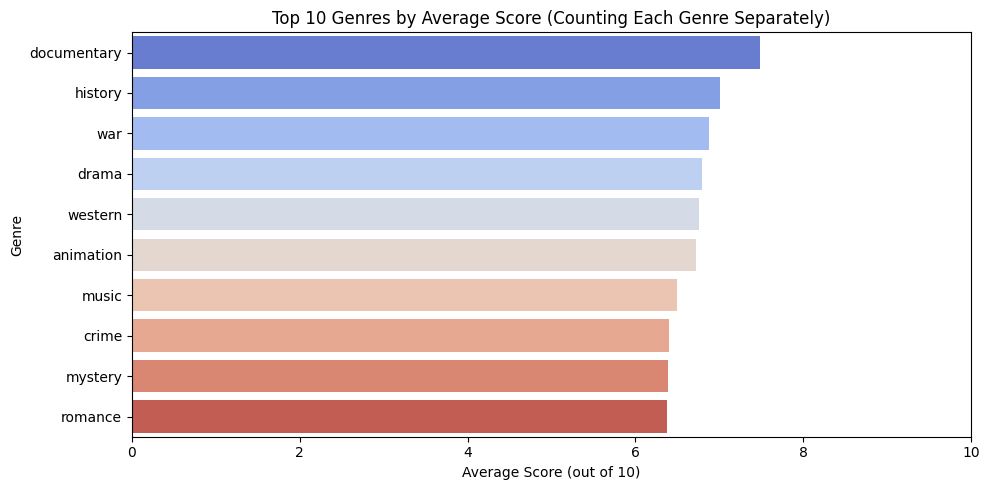

/tmp/ipython-input-2609505349.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.values, y=lang_counts.index, palette="mako")


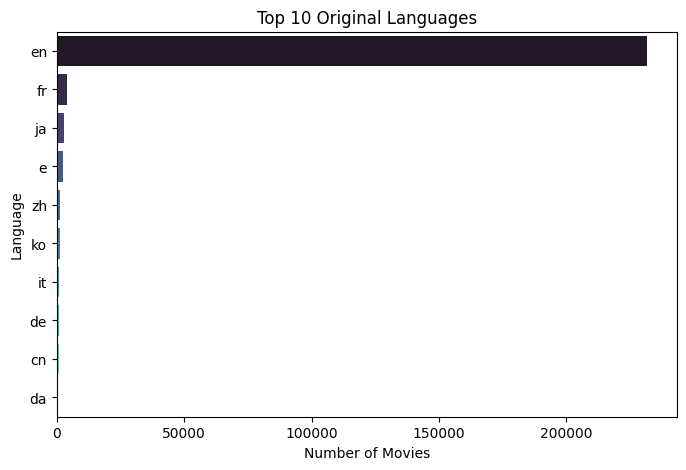

Top 10 Movies by Rating:


,Title,numeric_score_out_of_10,Genre
362532,nomadland,10.0,drama
362496,nomadland,10.0,drama
192358,mank,10.0,drama history
33757,pulp fiction,10.0,thriller crime
33759,pulp fiction,10.0,thriller crime
33760,pulp fiction,10.0,thriller crime
33763,pulp fiction,10.0,thriller crime
33765,pulp fiction,10.0,thriller crime
192370,mank,10.0,drama history
192391,mank,10.0,drama history


Bottom 10 Movies by Rating:


,Title,numeric_score_out_of_10,Genre
56279,logan lucky,0.0,action comedy crime drama
127481,little giant,0.0,comedy family
269091,unaccompanied minor,0.0,comedy family
269084,unaccompanied minor,0.0,comedy family
269071,unaccompanied minor,0.0,comedy family
252951,return to never land,0.0,adventure fantasy animation family
205223,jonah hex,0.0,action western drama fantasy thriller
154029,the apparition,0.0,horror thriller
238915,down periscope,0.0,comedy
305610,thunderbird,0.0,action adventure comedy family fantasy science...


In [58]:
# Distribution of numeric scores

plt.figure(figsize=(8,5))
sns.kdeplot(data=movies_df, x="numeric_score_out_of_10", fill=False, color="black", linewidth=2)
plt.title("Distribution of Movie Scores (out of 10)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

print("Average score:", movies_df["numeric_score_out_of_10"].mean())
print("Standard deviation:", movies_df["numeric_score_out_of_10"].std())

# Genre analysis

genre_exploded = movies_df.assign(Genre=movies_df["Genre"].str.split()).explode("Genre")

genre_exploded["Genre"] = genre_exploded["Genre"].astype(str).str.strip().str.lower()

genre_exploded = genre_exploded[genre_exploded["Genre"].notna() & (genre_exploded["Genre"] != "")]

top_genres = genre_exploded["Genre"].value_counts().head(10)
print("Top 10 Most Common Genres:\n", top_genres)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title("Top 10 Most Common Genres (Counting Each Genre Separately)")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

genre_scores = (
    genre_exploded.groupby("Genre")["numeric_score_out_of_10"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print("Top 10 Genres by Average Score:\n", genre_scores)

plt.figure(figsize=(10, 5))
sns.barplot(x=genre_scores.values, y=genre_scores.index, palette="coolwarm")
plt.title("Top 10 Genres by Average Score (Counting Each Genre Separately)")
plt.xlabel("Average Score (out of 10)")
plt.ylabel("Genre")
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

# Original language distribution

lang_counts = movies_df["Original_Language"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=lang_counts.values, y=lang_counts.index, palette="mako")
plt.title("Top 10 Original Languages")
plt.xlabel("Number of Movies")
plt.ylabel("Language")
plt.show()

# Top 10 movies
print("Top 10 Movies by Rating:")
display(movies_df[['Title', 'numeric_score_out_of_10', 'Genre']].sort_values(by='numeric_score_out_of_10', ascending=False).head(10))

# Bottom 10 movies
print("Bottom 10 Movies by Rating:")
display(movies_df[['Title', 'numeric_score_out_of_10', 'Genre']].sort_values(by='numeric_score_out_of_10', ascending=True).head(10))

In [59]:
# One row per movie, using the mean score from all its reviews
movie_level_df = (
    movies_df
    .groupby("Title", as_index=False)
    .agg(
        avg_score=("numeric_score_out_of_10", "mean"),
        n_reviews=("numeric_score_out_of_10", "size"),
        min_score=("numeric_score_out_of_10", "min"),
        max_score=("numeric_score_out_of_10", "max"),
        # optional: keep most common language & a combined genre field
        language=("Original_Language", lambda x: x.mode().iat[0]),
        genres=("Genre", lambda x: " ".join(sorted(set(" ".join(x).split()))),
    )
)
)

# If you just want average score as the "single numeric score"
movie_level_df["avg_score"] = movie_level_df["avg_score"].round(2)

display(movie_level_df.head(10)) # sample

,Title,avg_score,n_reviews,min_score,max_score,language,genres
0,10 cloverfield lane,7.46,215,2.000000,10.000000,en,drama fiction horror science thriller
1,10 minute gone,2.75,4,2.000000,3.262555,en,action crime mystery thriller
2,10 thing i hate about you,6.42,50,2.000000,10.000000,en,comedy drama romance
3,100 girl,6.34,4,6.000000,7.100000,en,comedy drama romance
4,1000 mile from christmas,4.88,2,3.750000,6.000000,e,comedy romance
5,101 dalmatian,8.50,30,6.000000,10.000000,en,comedy family
6,102 dalmatian,4.82,32,1.000000,9.000000,en,comedy family
7,10x10,5.17,6,3.750000,6.466363,en,thriller
8,12 hour shift,6.56,56,3.262555,10.000000,en,comedy crime horror thriller
9,12 mighty orphan,6.04,66,2.000000,8.750000,en,drama history


In [60]:
movie_reviews_table = (
    movies_df
    .sort_values(["Title", "numeric_score_out_of_10"], ascending=[True, False])
    [["Title", "numeric_score_out_of_10", "originalScore", "reviewText"]]
)

display(movie_reviews_table.head(50))  # shows reviews, visually grouped by Title

,Title,numeric_score_out_of_10,originalScore,reviewText
36365,10 cloverfield lane,10.000000,5/5,it is a refreshing take on a familiar concept ...
36388,10 cloverfield lane,10.000000,5/5,sequel or not there s no doubt that 10 cloverf...
36407,10 cloverfield lane,10.000000,5/5,it s a decent piece of low budget film making ...
36424,10 cloverfield lane,10.000000,4/4,when sequel even lateral one outdo their origi...
36425,10 cloverfield lane,10.000000,4/4,10 cloverfield lane might not be a true sequel...
36496,10 cloverfield lane,10.000000,5/5,reinvigorating the horror genre with a slick d...
36553,10 cloverfield lane,10.000000,4/4,put this down close this tab go to your local ...
36583,10 cloverfield lane,10.000000,4/4,goodman ha given one of my favorite performanc...
36637,10 cloverfield lane,10.000000,4/4,unpredictability in cinema is frequently a mis...
36433,10 cloverfield lane,9.000000,4.5/5,to tell you all the reason why 10 cloverfield ...


In [61]:
reviews_grouped_df = (
    movies_df
    .groupby("Title", as_index=False)
    .agg(
        avg_score=("numeric_score_out_of_10", "mean"),
        n_reviews=("numeric_score_out_of_10", "size"),
        reviews=("reviewText", lambda x: " || ".join(x))
    )
)

display(reviews_grouped_df.head(100))

,Title,avg_score,n_reviews,reviews
0,10 cloverfield lane,7.460443,215,8220 10 cloverfield lane 8221 ratchet down on ...
1,10 minute gone,2.754185,4,10 minute gone start out with most of a gang p...
2,10 thing i hate about you,6.423753,50,this is the magic behind the 10 thing i hate a...
3,100 girl,6.337500,4,you could certainly do worse || far from the t...
4,1000 mile from christmas,4.875000,2,actor tamar nova carry this lighthearted spani...
...,...,...,...,...
95,a good a it get,7.500536,55,a charming romantic comedy that will make you ...
96,a good day to die hard,4.206139,17,8220 a good day to die hard 8221 is missing al...
97,a good old fashioned orgy,4.617674,50,sudeikis in his first starring vehicle kind of...
98,a guy thing,4.400175,83,forgettable yet mostly watchable || a truly di...


# Split and Aggregate Dataset

In [62]:
# Save cleaned dataset and splits
from sklearn.model_selection import train_test_split

unique_movie_ids = movies_df['id'].unique()
train_ids, test_ids = train_test_split(unique_movie_ids, test_size=0.15, random_state=42)
val_ids, test_ids = train_test_split(test_ids, test_size=0.5, random_state=42)

train = movies_df[movies_df['id'].isin(train_ids)]
val = movies_df[movies_df['id'].isin(val_ids)]
test = movies_df[movies_df['id'].isin(test_ids)]

train.to_parquet('./train_movies_df.parquet', index=False)
val.to_parquet('./val_movies_df.parquet', index=False)
test.to_parquet('./test_movies_df.parquet', index=False)

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

# Aggregate the textual data into one unified feature for each movie
train['combined_text'] = train['Title'] + ' ' + train['Overview'] + ' ' + train['reviewText']
val['combined_text'] = val['Title'] + ' ' + val['Overview'] + ' ' + val['reviewText']
test['combined_text'] = test['Title'] + ' ' + test['Overview'] + ' ' + test['reviewText']

Train shape: (211813, 15)
Validation shape: (18536, 15)
Test shape: (19167, 15)


/tmp/ipython-input-611950839.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['combined_text'] = train['Title'] + ' ' + train['Overview'] + ' ' + train['reviewText']
/tmp/ipython-input-611950839.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['combined_text'] = val['Title'] + ' ' + val['Overview'] + ' ' + val['reviewText']
/tmp/ipython-input-611950839.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [63]:
# Basic recommender by genre
def popularity_recommender_by_genre(df, genre=None, top_k=10):
    if genre:
        genre_df = df[df['Genre'].str.contains(genre, na=False)]
    else:
        genre_df = df.copy()
    ranked = genre_df.groupby('Title', as_index=False)['numeric_score_out_of_10'].mean()
    return ranked.sort_values('numeric_score_out_of_10', ascending=False).head(top_k)

print(popularity_recommender_by_genre(movies_df, 'comedy'))

# Calculate TF-IDF and Cosine Similarity
train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)

vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1,2))
tfidf_matrix = vectorizer.fit_transform(train['combined_text'])

# Find similar movies
def recommend_tfidf(title, df=train, top_k=10):
    idx = df[df['Title'] == title].index
    if len(idx) == 0:
        print("Movie not found.")
        return None
    idx = idx[0]
    cosine_sim = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    top_indices = cosine_sim.argsort()[-top_k-1:][::-1][1:]  # exclude self
    recs = df.iloc[top_indices][['Title', 'Genre', 'numeric_score_out_of_10']]
    recs['similarity'] = cosine_sim[top_indices]
    return recs

recommend_tfidf('titanic')

                        Title  numeric_score_out_of_10
246                city light                 9.529685
975          some like it hot                 9.402339
731               modern time                 9.323611
830                  playtime                 9.316323
1206                toy story                 9.129627
94                 annie hall                 9.065211
1207              toy story 2                 9.034401
370            fearless hyena                 9.000000
118        back to the future                 8.974392
1266  who framed roger rabbit                 8.858664


,Title,Genre,numeric_score_out_of_10,similarity
200905,titanic,drama romance,7.000000,0.809207
201215,titanic,drama romance,4.864459,0.808866
201081,titanic,drama romance,10.000000,0.808157
201115,titanic,drama romance,10.000000,0.807816
201165,titanic,drama romance,5.000000,0.805355
200951,titanic,drama romance,3.000000,0.804932
201181,titanic,drama romance,10.000000,0.804296
201155,titanic,drama romance,10.000000,0.803642
201159,titanic,drama romance,10.000000,0.803060
201031,titanic,drama romance,8.000000,0.802654


# Initial Transformer Model

In [64]:
movies_df['combined_text'] = (
    movies_df['Title'].astype(str) + ' ' +
    movies_df['Overview'].astype(str) + ' ' +
    movies_df['reviewText'].astype(str)
)

In [65]:
movie_catalog = (
    movies_df
    .groupby('id', as_index=False)
    .agg(
        Title=('Title', lambda x: x.iloc[0]),
        Genre=('Genre', lambda x: ' '.join(sorted(set(' '.join(x).split())))),
        combined_text=('combined_text', lambda x: ' '.join(x)),
        avg_score=('numeric_score_out_of_10', 'mean'), # Average Rating
        n_reviews=('numeric_score_out_of_10', 'size') # Size
    )
)

# Keep a safe copy with a nice index
movie_catalog = movie_catalog.reset_index(drop=True)
print(movie_catalog.head())


                          id                     Title  \
0  1000_miles_from_christmas  1000 mile from christmas   
1                  100_girls                  100 girl   
2             101_dalmatians             101 dalmatian   
3             102_dalmatians             102 dalmatian   
4        10_cloverfield_lane       10 cloverfield lane   

                                   Genre  \
0                         comedy romance   
1                   comedy drama romance   
2                          comedy family   
3                          comedy family   
4  drama fiction horror science thriller   

                                       combined_text  avg_score  n_reviews  
0  1000 mile from christmas an auditor who comple...   4.875000          2  
1  100 girl this sexy teen comedy is about a fres...   6.337500          4  
2  101 dalmatian an evil high fashion designer pl...   8.495683         30  
3  102 dalmatian get ready for a howling good tim...   4.820547         32  
4

In [66]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Encode all movies
movie_embeddings = model.encode(
    movie_catalog['combined_text'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
    batch_size=64,
    normalize_embeddings=True
)


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

In [67]:
def recommend_hybrid(user_description, top_k=10, candidate_pool=300):
    # Encode user description
    query_emb = model.encode(
        [user_description],
        convert_to_numpy=True,
        normalize_embeddings=True
    )[0]

    sims = movie_embeddings @ query_emb

    # Take top-N most similar movies as candidates
    candidate_pool = min(candidate_pool, len(movie_catalog))
    top_sim_indices = np.argsort(sims)[::-1][:candidate_pool]

    candidates = movie_catalog.iloc[top_sim_indices].copy()
    candidates['similarity'] = sims[top_sim_indices]

    candidates = candidates.sort_values(
        by='similarity',
        ascending=False
    )

    return candidates[['Title', 'Genre', 'avg_score', 'n_reviews', 'similarity']].head(top_k)

In [68]:
query = "train comedy movie"
recommendations = recommend_hybrid(query, top_k=10)
display(recommendations)

,Title,Genre,avg_score,n_reviews,similarity
2166,money train,action comedy crime,5.005169,9,0.500004
3055,t2 trainspotting,crime drama,6.973796,175,0.479193
3447,the new adventure of aladdin,adventure comedy,2.000000,1,0.477053
286,another gay movie,comedy romance,5.288153,6,0.467423
2697,runaway train,action adventure drama thriller,7.367667,17,0.444837
3712,trainspotting,crime drama,8.437219,58,0.444184
2037,malibu rescue,action comedy family,4.000000,1,0.441348
1561,hot tub time machine,adventure comedy fiction science,6.204572,175,0.437370
717,chaser,comedy romance,4.000000,1,0.435189
3232,the dude in me,comedy fantasy,7.000000,2,0.426469


## Improved Model

In [ ]:
from sentence_transformers import CrossEncoder

In [ ]:
movie_catalog['overview_text'] = movies_df.groupby('id')['Overview'].apply(lambda x: ' '.join(x)).reset_index(drop=True)

<span style="color: green;"> Loading a BERT-based cross-encoder model for a better model. </span>

In [ ]:
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

In [ ]:
def rerank_with_cross_encoder(user_query, candidates_df, top_k=10):
    """
    Re-rank candidate movies using cross-encoder over all text fields
    (title, overview, reviews).
    """
    texts = candidates_df['combined_text'].tolist()
    pairs = [(user_query, t) for t in texts]

    scores = cross_encoder.predict(pairs)

    candidates_df = candidates_df.copy()
    candidates_df['cross_score'] = scores

    return candidates_df.sort_values('cross_score', ascending=False).head(top_k)

<span style="color: green;"> Filter so that the results reflect not only the semantic meaning of the user’s query, but also the explicit constraints the user expresses—such as wanting a “bad movie,” a “highly rated film,” or something within a specific genre. By applying score-based filters and genre-based filters, the system first narrows down the dataset to movies that satisfy the user's explicit preferences. Only then does it rank them using embedding similarity and cross-encoder reranking. </span>

In [ ]:
def apply_filters(df, user_query):
    q = user_query.lower()

    # Rating-based filters
    if "bad" in q or "worst" in q or "low rated" in q:
        df = df[df['avg_score'] < 4.5]

    if "good" in q or "great" in q or "highly rated" in q:
        df = df[df['avg_score'] >= 7.0]

    # Genre-based filtering
    for g in ["horror", "comedy", "drama", "romance", "thriller", "action", "fantasy", "adventure"]:
        if g in q:
            df = df[df['Genre'].str.contains(g, na=False)]

    return df

In [ ]:
def smart_movie_recommender(user_query, top_k=10, candidate_pool=300):
    query_emb = model.encode([user_query], convert_to_numpy=True, normalize_embeddings=True)[0]
    sims = movie_embeddings @ query_emb

    # select top candidates
    top_indices = np.argsort(sims)[::-1][:candidate_pool]
    candidates = movie_catalog.iloc[top_indices].copy()
    candidates['similarity'] = sims[top_indices]

    # Apply rating/genre filters based on query
    candidates = apply_filters(candidates, user_query)

    if len(candidates) == 0:
        print("No movies match filters — returning top semantic matches instead.")
        candidates = movie_catalog.iloc[top_indices].copy()

    # cross-encoder final reranking
    final = rerank_with_cross_encoder(user_query, candidates, top_k=top_k)

    return final[['Title', 'Genre', 'avg_score', 'n_reviews', 'similarity', 'cross_score']]

In [ ]:
smart_movie_recommender("Romance movie on a boat that eventually crashes into an iceberg")


,Title,Genre,avg_score,n_reviews,similarity,cross_score
3404,the longest ride,drama romance,4.501499,93,0.307508,-4.010417
3674,titanic,drama romance,8.176819,330,0.310776,-4.526784
2386,overboard,comedy romance,5.214899,42,0.289539,-5.791218
3441,the mountain between u,adventure drama romance,5.154105,129,0.371096,-5.941799
3754,two night stand,comedy romance,4.976999,37,0.347829,-6.248810
3019,summer of 85,drama romance,6.527684,61,0.384285,-6.552122
3412,the lover,action adventure fiction romance science,6.091198,2,0.424419,-6.570956
924,dear john,drama romance war,4.778203,108,0.294868,-6.618589
446,before we go,comedy drama romance,4.662792,19,0.342040,-6.823850
3408,the lost city,action adventure comedy romance,6.408327,137,0.303337,-7.208194


<span style="color: green;"> Turn this into a text based output. </span>

In [ ]:
def summarize_reviews(text, max_len=2):
    """
    Produces a simple summary of the reviews.
    """
    sentences = text.split(".")
    cleaned_sentences = []

    for s in sentences:
        stripped = s.strip()           # Remove leading/trailing whitespace
        length = len(stripped)

        if length > 40:                # Keep only sentences longer than 40 characters
            cleaned_sentences.append(stripped)

    sentences = cleaned_sentences


    if len(sentences) == 0:
        return "Reviewers did not provide substantial feedback."

    return ". ".join(sentences[:max_len]) + "."

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os, getpass

In [ ]:
if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

<span style="color: green;"> Using existing LLM to turn answer into comprehensive (and humanlike) text form. </span>

In [ ]:
MODEL_NAME = "gemini-2.0-flash"
llm = ChatGoogleGenerativeAI(model=MODEL_NAME, temperature=0)

In [ ]:
recommendation_prompt = PromptTemplate(template="""
You are a movie recommendation assistant.

The user asked: "{user_query}"

Below is structured information about the recommended movies:
{movie_data}

Write a detailed, conversational, human-like recommendation paragraph.
Requirements:
- Mention each movie by name.
- Explain why it fits the user's query.
- Include what reviewers generally said, based on the provided summaries.
- Do NOT output bullet points; use flowing prose.
- Do NOT invent facts not supported by the summaries.

Write your response in plain text only, with only the movie name italicized.
""",
    input_variables=["user_query", "movie_data"],
)

**Giving LLM:**

- **Title**

- **Genre**

- **Score**

- **Summary of User opinions**


In [ ]:
def build_llm_context(results, movies_df, top_n=5):
    movie_entries = []

    for _, row in results.head(top_n).iterrows():
        title = row["Title"].title()
        genre = row["Genre"]
        score = float(row["avg_score"])

        # Combine reviews
        reviews = movies_df[movies_df["Title"] == row["Title"]]["reviewText"]
        full_reviews = " ".join(reviews.tolist())
        review_summary = summarize_reviews(full_reviews)

        movie_entries.append({
            "title": title,
            "genre": genre,
            "avg_score": score,
            "review_summary": review_summary
        })

    return movie_entries

In [ ]:
parser = StrOutputParser()

recommendation_chain = recommendation_prompt | llm | parser

In [ ]:
def generate_recommendation_paragraph_gemini(user_query, results, movies_df, top_n=5):
    movie_data = build_llm_context(results, movies_df, top_n)

    formatted_movie_data = ""
    for movie in movie_data:
        formatted_movie_data += (
            f"- Title: {movie['title']}\n"
            f"  Genre: {movie['genre']}\n"
            f"  Avg Score: {movie['avg_score']}\n"
            f"  Review Summary: {movie['review_summary']}\n\n"
        )

    output = recommendation_chain.invoke({
        "user_query": user_query,
        "movie_data": formatted_movie_data
    })

    return output

In [ ]:
query = "romance movie on a boat that eventually crashes into an iceberg"
results = smart_movie_recommender(query, top_k=10)

paragraph = generate_recommendation_paragraph_gemini(query, results, movies_df, top_n=5)
print(paragraph)

Okay, I can help with that! For a romance movie on a boat that eventually crashes into an iceberg, the obvious choice is *Titanic*. It's a drama romance where a doomed luxury liner crashes into an iceberg. Reviewers call it a modern classic, simple and archetypal, but powerful. They praise the casting of the leads and the film's emotional impact, with some calling it a profound experience and a great film.

I can also suggest *The Longest Ride*, though it doesn't quite fit your request. It's a drama romance, but it doesn't take place on a boat or involve an iceberg. Reviewers say it's another Nicholas Sparks adaptation, corny but with old-fashioned charm. Some found it weighed down by unnecessary storylines and clichés, while others enjoyed the performances and the neat twist in the tale.

*Overboard* is another option, but it only partially fits. It's a comedy romance that involves a boat, but there's no iceberg crash. Reviewers say it's a piece of piffle that stays afloat thanks to t

## Evaluation


In [84]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import math
import numpy as np

In [85]:
# Aggregate all reviews per movie
reviews_agg = (
    movies_df
    .groupby("id")["reviewText"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
    .rename(columns={"reviewText": "all_reviews"})
)

**The Issue with the Original Data:**
- The original dataset has **one row per review**.
- Movies appear many times.
  - Example: *Titanic* with 1,000 reviews → 1,000 rows.
- Searching this table would return lots of **duplicate results for the same movie**.

---

**The Fix: `movie_catalog`**
- We build a catalog with **one row per movie**.
- All text for a movie (title, overview, reviews) is **combined into one document**.
- Each movie appears **once**, with a unique ID.

---

**Why This Is Needed for Evaluation**
- **Goal:** Given a review, find the correct movie.
- **Query:** One review from the test set.
- **Search space:** A list of unique movies (`movie_catalog`).
- The retriever compares the review to each movie document.
- If it works, the correct movie (e.g., *Titanic*) ranks near the top.

In [86]:
movie_catalog = movie_catalog.merge(reviews_agg, on="id", how="left")
movie_catalog["all_reviews"] = movie_catalog["all_reviews"].fillna("")

**Evaluation Process**

- **Select a review from the test set**
  - Randomly sample or explicitly choose one review instance.
  - Ensure it was not seen during training.

- **Use the review text as the query**
  - Input the raw review text into the semantic retriever.
  - Do not include metadata such as movie title or ID in the query.

- **Define the relevant item**
  - The relevant (ground-truth) item is the **movie ID** associated with the selected review.

- **Run the semantic retriever**
  - Search over the **entire movie catalog**.
  - Retrieve a ranked list of candidate movies based on semantic similarity.

- **Check the rank of the correct movie**
  - Identify where the ground-truth movie ID appears in the ranked results.
  - Record its rank (e.g., top-1, top-5, top-10, etc.).

- **Evaluation objective**
  - Measure whether the system can retrieve the correct movie using **review text alone**.
  - This evaluates semantic understanding rather than keyword overlap.


In [87]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    movie_catalog["combined_text"].astype(str)
)

In [88]:
def retrieve_tfidf(query, top_k=200):
    q_vec = tfidf_vectorizer.transform([query])
    sims = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_idx = np.argsort(sims)[::-1][:top_k]
    return top_idx


In [89]:
# Initial Model - SBERT
def retrieve_sbert(query, top_k=200):
    q_emb = model.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
    sims = movie_embeddings @ q_emb
    top_idx = np.argsort(sims)[::-1][:top_k]
    return top_idx

In [90]:
def retrieve_two_stage(query, top_k=10, candidate_pool=200):
    """
    Two-stage retrieval:
    1) Dense retrieval to get a candidate set
    2) Cross-encoder re-ranking to select the best results
    """

    query_embedding = model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )[0]

    similarity_scores = movie_embeddings @ query_embedding

    top_candidate_indices = np.argsort(similarity_scores)[::-1][:candidate_pool]

    candidates = movie_catalog.iloc[top_candidate_indices].copy()

    text_pairs = [
        (query, text)
        for text in candidates["combined_text"].tolist()
    ]

    cross_scores = cross_encoder.predict(text_pairs)

    candidates["cross_score"] = cross_scores
    candidates = (
        candidates
        .sort_values("cross_score", ascending=False)
        .head(top_k)
    )
    return candidates.index.values


In [91]:
"""
The Following evaluates a semantic retrieval model using review text as the query.

For each sampled review from the test set:
- The review text is used as the retrieval query.
- The relevant (ground-truth) item is the movie ID the review belongs to.
- The retriever is run over the full movie catalog.
- The rank of the correct movie is identified.
- Single-relevant-item retrieval metrics are computed
  (Precision@K, Recall@K, NDCG@K, and MRR).

Returns the average of these metrics across all evaluated queries,
measuring how well the system can retrieve the correct movie from
review text alone.
"""

'\nThe Following evaluates a semantic retrieval model using review text as the query.\n\nFor each sampled review from the test set:\n- The review text is used as the retrieval query.\n- The relevant (ground-truth) item is the movie ID the review belongs to.\n- The retriever is run over the full movie catalog.\n- The rank of the correct movie is identified.\n- Single-relevant-item retrieval metrics are computed\n  (Precision@K, Recall@K, NDCG@K, and MRR).\n\nReturns the average of these metrics across all evaluated queries,\nmeasuring how well the system can retrieve the correct movie from\nreview text alone.\n'

In [92]:
# Make sure we have a lookup from catalog row index -> movie id
catalog_ids = movie_catalog["id"].values

def metrics_single_relevant(rank, k):
    if rank is None or rank > k:
        return 0.0, 0.0, 0.0, 0.0
    precision = 1.0 / k
    recall = 1.0
    ndcg = 1.0 / math.log2(rank + 1)
    mrr = 1.0 / rank
    return precision, recall, ndcg, mrr

In [93]:
def evaluate_model(test_df, retrieve_fn, k=10, n_queries=500, seed=42):
    sample = (
        test_df
        .dropna(subset=["reviewText", "id"])
        .sample(n=min(n_queries, len(test_df)), random_state=seed)
    )

    precisions, recalls, ndcgs, mrrs = [], [], [], []

    for _, row in sample.iterrows():
        query = str(row["reviewText"])
        true_id = row["id"]

        retrieved_idx = retrieve_fn(query)
        retrieved_ids = catalog_ids[retrieved_idx]

        hits = np.where(retrieved_ids == true_id)[0]
        rank = int(hits[0] + 1) if len(hits) else None

        p, r, n, m = metrics_single_relevant(rank, k)
        precisions.append(p)
        recalls.append(r)
        ndcgs.append(n)
        mrrs.append(m)

    return {
        "Precision@K": np.mean(precisions),
        "Recall@K": np.mean(recalls),
        "NDCG@K": np.mean(ndcgs),
        "MRR": np.mean(mrrs),
        "n_eval": len(precisions)
    }

In [94]:
K = 10

results = {
    "TF-IDF": evaluate_model(
        test,
        retrieve_fn=lambda q: retrieve_tfidf(q, top_k=200),
        k=K,
        n_queries=200
    ),

    "SBERT": evaluate_model(
        test,
        retrieve_fn=lambda q: retrieve_sbert(q, top_k=200),
        k=K,
        n_queries=200
    ),

    "Two-Stage": evaluate_model(
        test,
        retrieve_fn=lambda q: retrieve_two_stage(q, top_k=K, candidate_pool=200),
        k=K,
        n_queries=100  # fewer due to cross-encoder cost
    )
}

results_df = pd.DataFrame(results).T
display(results_df)

,Precision@K,Recall@K,NDCG@K,MRR,n_eval
TF-IDF,0.032,0.32,0.237218,0.211534,200.0
SBERT,0.032,0.32,0.236412,0.210657,200.0
Two-Stage,0.033,0.33,0.275338,0.257000,100.0


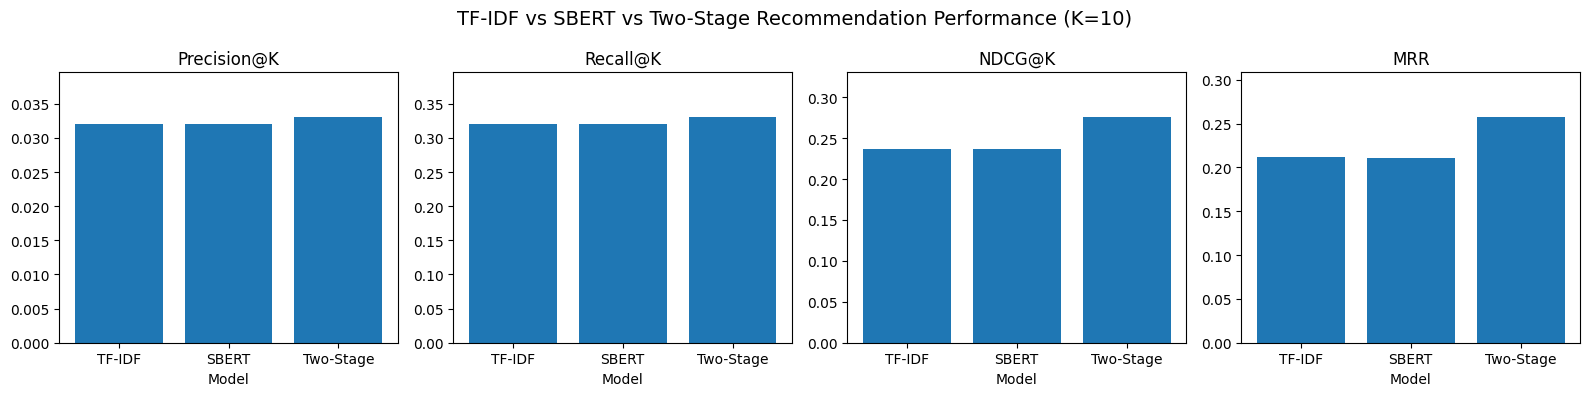

In [95]:
metrics = ["Precision@K", "Recall@K", "NDCG@K", "MRR"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric])
    axes[i].set_title(metric)
    axes[i].set_ylim(0, results_df[metric].max() * 1.2)
    axes[i].set_xlabel("Model")

plt.suptitle("TF-IDF vs SBERT vs Two-Stage Recommendation Performance (K=10)", fontsize=14)
plt.tight_layout()
plt.show()

<span style="color: green;">  We compared our proposed two-stage recommendation system against a TF-IDF baseline and a SBERT bi-encoder model using Precision@K, Recall@K, NDCG@K, and MRR. While the SBERT bi-encoder performed similarly to TF-IDF on this review-to-movie retrieval task, the two-stage system consistently outperformed both baselines in ranking-sensitive metrics. In particular, the cross-encoder reranking stage yielded notable improvements in NDCG@10 and MRR, indicating that relevant movies were ranked higher and more consistently. These results demonstrate the effectiveness of joint query–document modeling beyond embedding similarity alone. </span>

<h1> MAP@k, Success Rate@k and Recall@R </h1>

In [96]:
catalog_ids = movie_catalog["id"].values

def average_precision_at_k(relevant_ids, retrieved_ids, k):
    relevant_ids = set(relevant_ids)
    hits = 0
    score = 0.0

    for i, doc_id in enumerate(retrieved_ids[:k], start=1):
        if doc_id in relevant_ids:
            hits += 1
            score += hits / i

    if len(relevant_ids) == 0:
        return 0.0

    return score / min(len(relevant_ids), k)


def success_rate_at_k(relevant_ids, retrieved_ids, k):
    return 1.0 if any(d in relevant_ids for d in retrieved_ids[:k]) else 0.0

In [97]:
def evaluate_model_trends_safe(test_df, retrieve_fn, k_values, n_queries=50 ,seed=42):
    sample = (
        test_df
        .dropna(subset=["reviewText", "id"])
        .sample(n=min(n_queries, len(test_df)), random_state=seed)
    )

    results = {
        "MAP": {k: [] for k in k_values},
        "SuccessRate": {k: [] for k in k_values},
    }

    for _, row in sample.iterrows():
        query = str(row["reviewText"])
        relevant_ids = [row["id"]]

        retrieved_idx = retrieve_fn(query)
        retrieved_ids = catalog_ids[retrieved_idx]

        for k in k_values:
            results["MAP"][k].append(
                average_precision_at_k(relevant_ids, retrieved_ids, k)
            )
            results["SuccessRate"][k].append(
                success_rate_at_k(relevant_ids, retrieved_ids, k)
            )

    return {
        metric: {x: np.mean(vals) for x, vals in metric_dict.items()}
        for metric, metric_dict in results.items()
    }

In [98]:
k_values = [1, 3, 5, 10, 20]

trend_results = {
    "TF-IDF": evaluate_model_trends_safe(
        test,
        retrieve_fn=lambda q: retrieve_tfidf(q, top_k=50),
        k_values=k_values,
        n_queries=100
    ),
    "SBERT": evaluate_model_trends_safe(
        test,
        retrieve_fn=lambda q: retrieve_sbert(q, top_k=50),
        k_values=k_values,
        n_queries=100
    ),
    "Two-Stage": evaluate_model_trends_safe(
        test,
        retrieve_fn=lambda q: retrieve_two_stage(q, top_k=max(k_values), candidate_pool=100),
        k_values=k_values,
        n_queries=50
    )
}

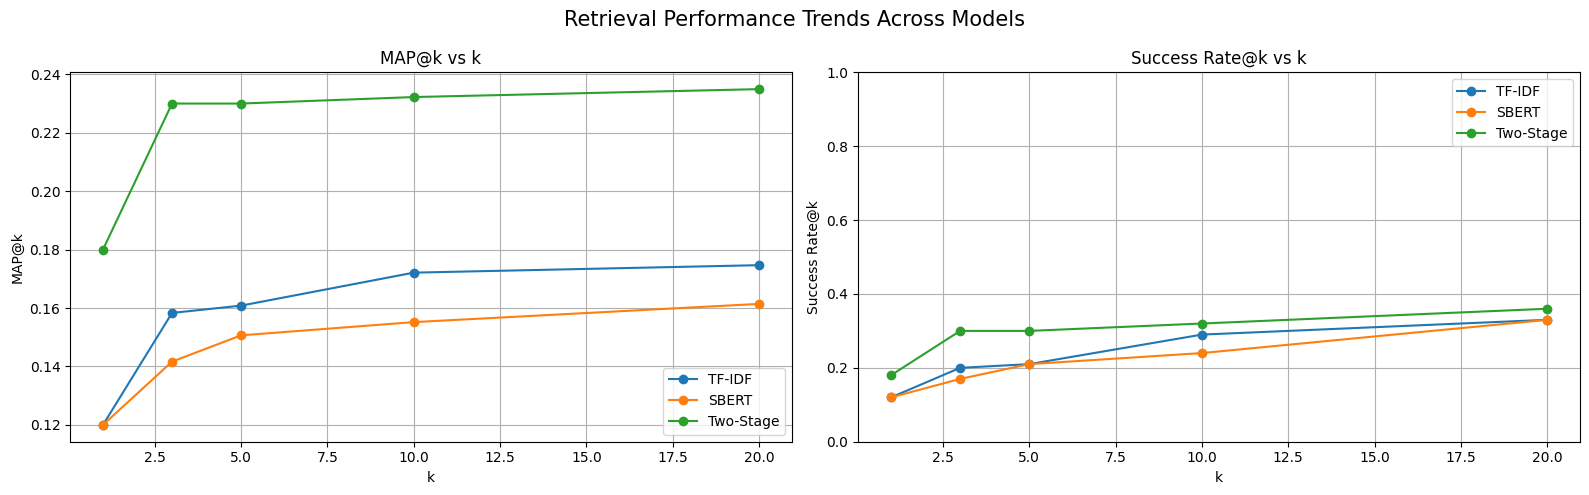

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MAP@k
for model, res in trend_results.items():
    ks = sorted(res["MAP"].keys())
    axes[0].plot(ks, [res["MAP"][k] for k in ks], marker="o", label=model)

axes[0].set_title("MAP@k vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("MAP@k")
axes[0].grid(True)
axes[0].legend()

# Success Rate@k
for model, res in trend_results.items():
    ks = sorted(res["SuccessRate"].keys())
    axes[1].plot(ks, [res["SuccessRate"][k] for k in ks], marker="o", label=model)

axes[1].set_title("Success Rate@k vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Success Rate@k")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Retrieval Performance Trends Across Models", fontsize=15)
plt.tight_layout()
plt.show()